In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [4]:
df = pd.read_csv("train.csv")  

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)


df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [ ]:
# After handling missing values, all columns in the dataset contain no missing values.
# This ensures the dataset is complete and ready for further analysis.

In [9]:
#Task 3: Detect Outliers using IQR
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
print("Number of outliers:", outliers.shape[0])

Number of outliers: 116


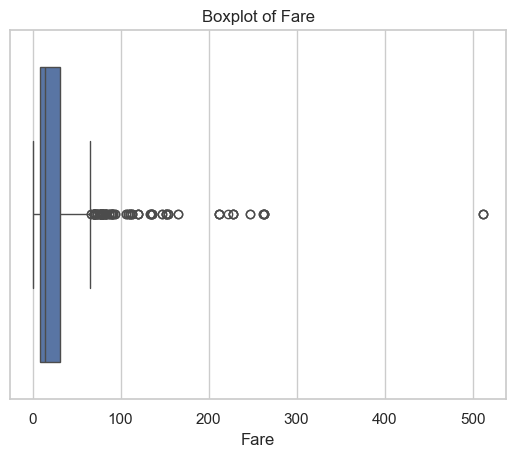

In [10]:
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare")
plt.show()

In [11]:
df['Fare'] = np.where(df['Fare'] > upper, upper, df['Fare'])
df['Fare'] = np.where(df['Fare'] < lower, lower, df['Fare'])

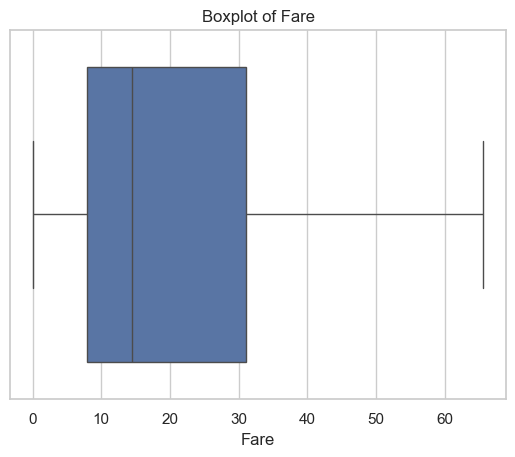

In [12]:
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare")
plt.show()

In [ ]:
# Outliers were detected using the Interquartile Range (IQR) method.
# The lower and upper bounds were calculated based on Q1 and Q3.
# A total of 116 outliers were identified in the Fare feature.

# To handle these outliers, capping was applied by limiting values to the calculated lower and upper bounds.
# This approach reduces the effect of extreme values without removing data points.

# After applying capping, the boxplot shows that the outliers have been reduced,
# resulting in a more balanced distribution of the Fare feature.

# This improves data quality and ensures more reliable analysis.

In [13]:
# Min-Max Normalization
df['Fare_MinMax'] = (df['Fare'] - df['Fare'].min()) / (df['Fare'].max() - df['Fare'].min())

# Z-score Normalization
df['Fare_Zscore'] = (df['Fare'] - df['Fare'].mean()) / df['Fare'].std()

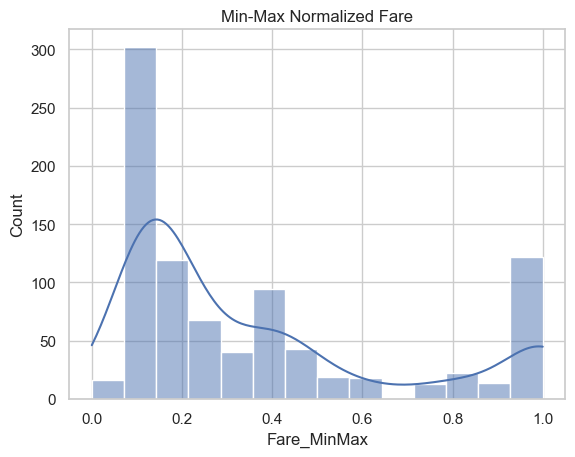

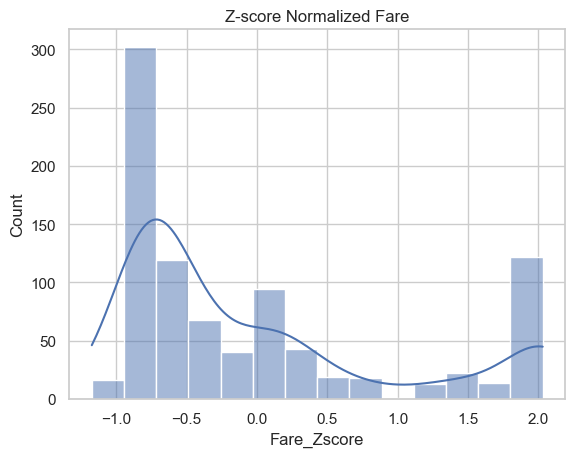

In [14]:
sns.histplot(df['Fare_MinMax'], kde=True)
plt.title("Min-Max Normalized Fare")
plt.show()

sns.histplot(df['Fare_Zscore'], kde=True)
plt.title("Z-score Normalized Fare")
plt.show()

In [15]:
#Task 5: Apply PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
features = df[['Age', 'Fare', 'Pclass']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.61814275 0.29657203]


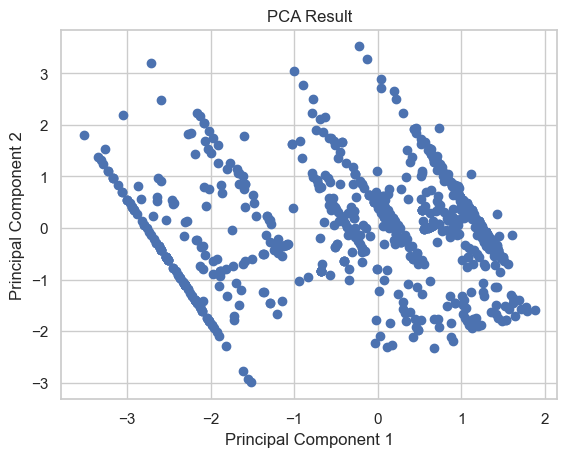

In [16]:
plt.scatter(pca_result[:,0], pca_result[:,1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Result')
plt.show()

In [ ]:
# The scatter plot shows the data projected onto the first two principal components.
# The data points are distributed across the new feature space, capturing the main patterns
# and variations in the dataset.